In [74]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import glob
import re
from matplotlib import colormaps
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
import json
import os, shutil, subprocess, time, hashlib
import pyarrow as pa, pyarrow.parquet as pq

#for event display
import sys
#path to event display directory - change with where your path is 
sys.path.append('/eos/user/s/staghayo/SWAN_projects/analysis_tools_local')
import importlib
import WCTE_event_display.EventDisplay

importlib.reload(WCTE_event_display.EventDisplay)

from WCTE_event_display.EventDisplay import EventDisplay

from scipy.optimize import curve_fit
from scipy.optimize import root_scalar


import pyarrow as pa, pyarrow.parquet as pq
import gc

sys.path.insert(0, "/eos/user/s/staghayo/SWAN_projects/Geometry") # Give your path to your geometry package
from Geometry.WCD import WCD
from Geometry.Device import Device


import tempfile
from typing import Optional, List

## Load in the data

Loading in the file, we can configure how many entries to load in. In the jupyer notebook all entries are loaded into memory so loading too many can cause issues. entry_start=0 and entry_stop=10000 can be altered to load more or less entries. It can also help to only load certain branches (such as all branches except the waveforms which contain the most data)

In [75]:
run_number = 1707

In [77]:
t0 = time.time()

# ---- inputs ------------------------------------------------------
#file_path = f"/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v0_5/{run_number}/WCTE_offline_R{run_number}S0_VME_matched.root"
#if your converted runs:
file_path = f"/eos/user/s/staghayo/SWAN_projects/analysis_tools_local/output/WCTE_offline_R{run_number}S0_VME_matched.root"




tree_name = "WCTEReadoutWindows"
N = 5000


branches = [
    "trigger_times", "trigger_types",
    "hit_pmt_times", "hit_pmt_calibrated_times",
    "window_data_quality", "window_time",
    "hit_mpmt_card_ids", "hit_pmt_readout_mask",
    "hit_mpmt_slot_ids", "hit_pmt_position_ids",
    "hit_pmt_channel_ids", "hit_pmt_charges"]
with uproot.open(file_path) as root_file:
    tree = root_file[tree_name]
    all_events = tree.arrays(entry_start=0,entry_stop=N,filter_name=branches,library="ak")


print(f"Loaded first {N} events in {time.time()-t0:.2f}s")

Loaded first 5000 events in 0.94s


To see the branches in the file

Load the metadata json to see a list of stable channels for the run. The channels are stored as a single integer defined as 100*mPMT_slot_id + pmt_position_id. This will be more useful later for comparisons to simulation. Other information here is the revision number of the timing constants and when they were inserted to the database, the run number and run configuration.

In [78]:
#file_path = "/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v0_5/1406/run_1406_meta_data_json.json"

#if your converted runs:
file_path = "/eos/user/s/staghayo/SWAN_projects/analysis_tools_local/output/run_1707_meta_data_json.json"


with open(file_path, "r") as f:
    metadata = json.load(f)
print(metadata.keys())

good_mpmt_channel_list = metadata["good_wcte_pmts"]
print(len(good_mpmt_channel_list),"wcte PMTs stably readout during the run")

print("The run configuration is",metadata["run_configuration"] )

dict_keys(['run_number', 'run_configuration', 'good_wcte_pmts', 'wcte_pmts_with_timing_constant', 'wcte_pmts_slow_control_stable', 'timing_constant_revision_id', 'timing_constant_insert_time'])
1562 wcte PMTs stably readout during the run
The run configuration is Good_mpmt_beam_v44


## Run configuration

The full run configuration for each run was saved in the online DAQ run and configuration database, this database has been dumped to json for ease of access on lxplus

You can explore the run configuration to get the window size, configuration of the RBU and configuration of each of the mPMTs


In [79]:
run_configuration_name = metadata["run_configuration"] 
config_file_path = "/eos/experiment/wcte/configuration/tooldaq_run_configs/configurations.json"
with open(config_file_path, 'r') as f:
    config_data = json.load(f)
run_config = config_data[run_configuration_name]

print(run_config['device_configs'].keys())

#e.g to get the window times
print("Window pre-trigger (in CC)",run_config['device_configs']['WCTE_RBU']['WindowBuilder']['main_pre_trigger'])
print("Window post-trigger (in CC)",run_config['device_configs']['WCTE_RBU']['WindowBuilder']['main_post_trigger'])

dict_keys(['MPMT1', 'MPMT3', 'MPMT6', 'MPMT7', 'MPMT8', 'MPMT10', 'MPMT11', 'MPMT12', 'MPMT14', 'MPMT15', 'MPMT16', 'MPMT17', 'MPMT18', 'MPMT19', 'MPMT20', 'MPMT21', 'MPMT22', 'MPMT23', 'MPMT24', 'MPMT25', 'MPMT26', 'MPMT27', 'MPMT28', 'MPMT29', 'MPMT30', 'MPMT31', 'MPMT32', 'MPMT33', 'MPMT34', 'MPMT35', 'MPMT36', 'MPMT38', 'MPMT40', 'MPMT41', 'MPMT42', 'MPMT43', 'MPMT44', 'MPMT45', 'MPMT46', 'MPMT47', 'MPMT48', 'MPMT52', 'MPMT71', 'MPMT73', 'MPMT74', 'MPMT75', 'MPMT76', 'MPMT77', 'MPMT78', 'MPMT79', 'MPMT80', 'MPMT82', 'MPMT83', 'MPMT84', 'MPMT85', 'MPMT86', 'MPMT87', 'MPMT89', 'MPMT91', 'MPMT92', 'MPMT93', 'MPMT94', 'MPMT96', 'MPMT97', 'MPMT98', 'MPMT99', 'MPMT100', 'MPMT101', 'MPMT102', 'MPMT103', 'MPMT104', 'MPMT105', 'MPMT106', 'MPMT107', 'MPMT108', 'MPMT109', 'MPMT111', 'MPMT112', 'MPMT113', 'MPMT114', 'MPMT115', 'MPMT117', 'MPMT118', 'MPMT130', 'MPMT131', 'MPMT132', 'WCTE_RBU'])
Window pre-trigger (in CC) 300
Window post-trigger (in CC) 700


In [80]:
## Verify in the data that the window size of the event is correct
trigger_times = []
hit_times = [] 

for event in all_events:
    #the trigger time of the main trigger
    trigger_times.append(event['trigger_times'][event['trigger_types']==3][0])

    hit_times.extend(event['hit_pmt_times'])


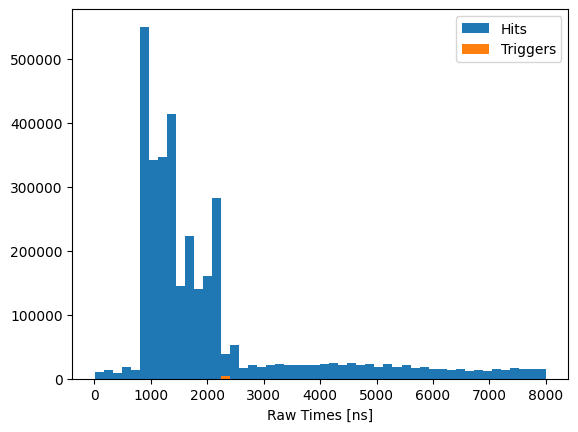

In [81]:
_, bins,_ = plt.hist(hit_times,bins =50, label = "Hits")
plt.hist(trigger_times, bins =bins, label = "Triggers")
plt.xlabel("Raw Times [ns]")
plt.legend()

## Timing calibration applied

So far we have plotted the raw hit timing, the files processed for the workshop have timing constants applied
If we plot the calibrated hit times we should expect the hits to arrive at similar time


Text(0.5, 0, 'Calibrated Times [ns]')

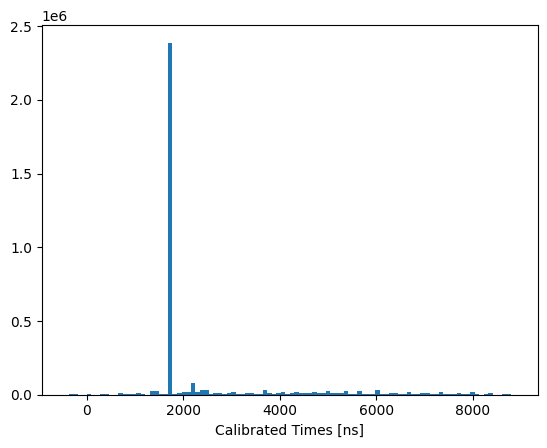

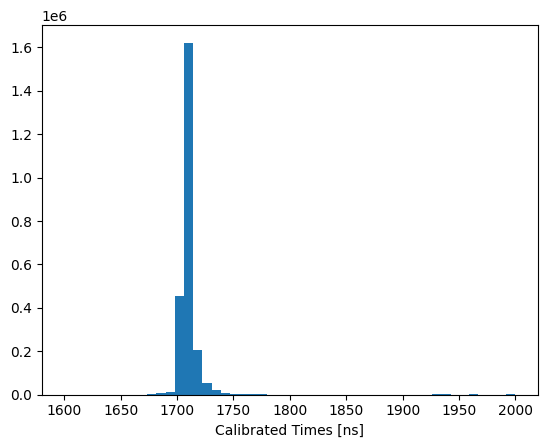

In [82]:
hit_pmt_calibrated_times = ak.flatten(all_events["hit_pmt_calibrated_times"])
plt.hist(hit_pmt_calibrated_times, bins =100)
plt.xlabel("Calibrated Times [ns]")
plt.show


t_min = 1600
t_max = 2000
plt.figure()
plt.hist(hit_pmt_calibrated_times, bins =np.linspace(t_min,t_max))
plt.xlabel("Calibrated Times [ns]")


Note that these are the times w.r.t the window start (which is with reference to the trigger signal which is on an 8ns clock cycle), 
the beam particle is not phaselocked to that 8ns clock (it can arrive anywhere within that 8ns clock cycle) and so there is a spread in times seen in this distribution. To produce a narrower time distribution we would need to subtract the timing from the beam monitor signal read in through the trigger mainboards. Dean has an example of this here: https://github.com/WCTE/mpmt_teststand/blob/main/jupyter/explore_wcte_root_dict.ipynb 



If we plot on a log scale we can see the bunch structure of our beam. Bunches in the beam are separated by ~300ns. Essentially where another particle enters the detector in the same window. 


In [83]:
t_min = 1670
t_max = 1770

Text(0.5, 0, 'Calibrated Times [ns]')

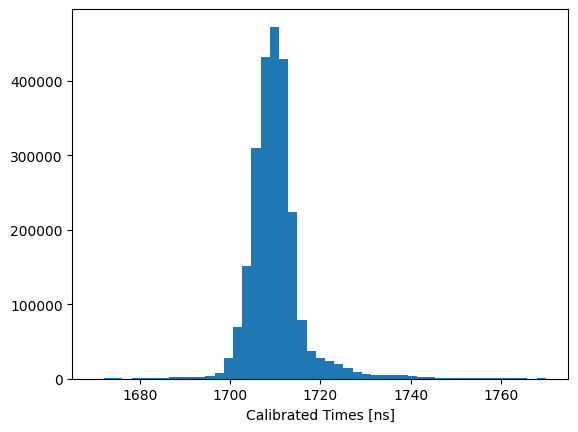

In [84]:
calibrated_times = plt.hist(hit_pmt_calibrated_times
         ,  bins =np.linspace(t_min,t_max)
        )
plt.xlabel("Calibrated Times [ns]")


## Data quality flags

#### 1) Window level flags
Limited data quality flags have been applied to the data based on known periods of readout failure. window_data_quality branch contains a flag for potential problems. 0= no potential problems found, 1= trigger effected by 67ms issue, 2= slow control data quality issues identified (e.g. dropped packets)

In [85]:
data_quality = [] 
window_times = [] 
for event in all_events:
    data_quality.append(event["window_data_quality"])
    window_times.append(event["window_time"])

window_times = np.array(window_times)

Text(0, 0.5, 'Window time % 2^26 ns')

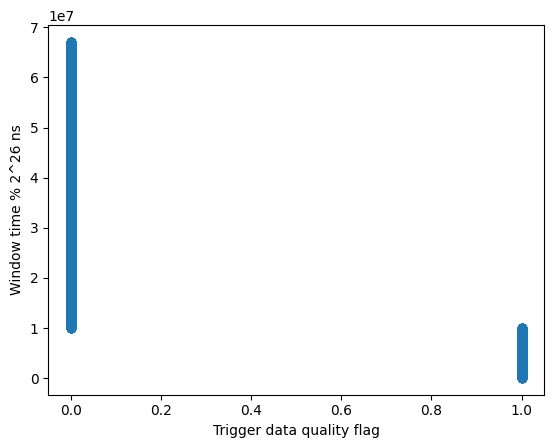

In [86]:
plt.scatter(data_quality,window_times%(2**26))
plt.xlabel("Trigger data quality flag")
plt.ylabel("Window time % 2^26 ns")

#### 2) Channel level flags
Flags have been applied to individual hits based on slow control data and availability of calibration constants for each channel. The channel mask is the same for all triggers in the run and defined as a bitmask 0= no potential problems found, 1= no calibration constant for channel issue, 2= slow control data quality issues

In [87]:
#e.g. look at the first 20 events and look at the number of hits which pass selection cuts
for ievent, event in enumerate(all_events[:20]):
    if (event['window_data_quality']!=0):
        print("Event excluded with flag",event['window_data_quality'])
        continue
    
    nhits = len(event['hit_pmt_times'])
    trigger_mainboard_hits = np.sum(event['hit_mpmt_card_ids']>120) # for trigger mainboards 130,131,132
    wcte_pmt_hits = np.sum((event['hit_mpmt_card_ids']<120))
    wcte_pmt_hits_pass_mask = np.sum((event['hit_mpmt_card_ids']<120) & (event['hit_pmt_readout_mask']==0))

    print("trigger_mainboard_hits",trigger_mainboard_hits,"wcte_pmt_hits",wcte_pmt_hits,"wcte_pmt_hits pass channel selection",wcte_pmt_hits_pass_mask)

Event excluded with flag 1
trigger_mainboard_hits 35 wcte_pmt_hits 804 wcte_pmt_hits pass channel selection 804
trigger_mainboard_hits 62 wcte_pmt_hits 780 wcte_pmt_hits pass channel selection 779
trigger_mainboard_hits 37 wcte_pmt_hits 638 wcte_pmt_hits pass channel selection 638
trigger_mainboard_hits 32 wcte_pmt_hits 645 wcte_pmt_hits pass channel selection 645
trigger_mainboard_hits 36 wcte_pmt_hits 298 wcte_pmt_hits pass channel selection 298
trigger_mainboard_hits 30 wcte_pmt_hits 395 wcte_pmt_hits pass channel selection 394
trigger_mainboard_hits 50 wcte_pmt_hits 682 wcte_pmt_hits pass channel selection 682
trigger_mainboard_hits 37 wcte_pmt_hits 723 wcte_pmt_hits pass channel selection 723
Event excluded with flag 1
trigger_mainboard_hits 29 wcte_pmt_hits 1033 wcte_pmt_hits pass channel selection 1032
trigger_mainboard_hits 34 wcte_pmt_hits 90 wcte_pmt_hits pass channel selection 90
trigger_mainboard_hits 26 wcte_pmt_hits 542 wcte_pmt_hits pass channel selection 539
trigger_mai

## Event display

Data quality flag 0
(2014,)


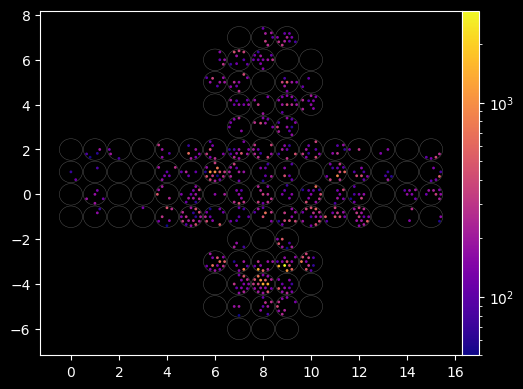

In [88]:

#create an instance of event diplay class
eventDisplay = EventDisplay() 
#load the positions of the mPMTs (an internal file to the event display class that 
#specificies where to plot and what orientation to plot mPMTs on the event display)
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
evID = 3115
#e.g. select a single event randomly
event = all_events[evID]
print("Data quality flag",event['window_data_quality'])

#apply a mask to hits, don't include hits labelled as bad or hits on trigger mainboards in the event display
hit_mask = (event['hit_pmt_readout_mask']==0) & (event['hit_mpmt_card_ids']<120)

pmt_slot = event['hit_mpmt_slot_ids'][hit_mask]
pmt_pos = event['hit_pmt_position_ids'][hit_mask]
data_to_plot  = event['hit_pmt_charges'][hit_mask]

#this function processes pmt positions and the data to plot into an array for use by the event display
#sum_data will sum data for the same channel e.g. if a channel has 2 hits in event['hit_pmt_charges'] they will be summed
#if summed data is false it will by default take the smallest value for each channel for plotting time distributions
ev_disp_data = eventDisplay.process_data(pmt_slot,pmt_pos,data_to_plot,sum_data=True)

#this pltos the event display, colors.Normalize() will plot on a linear scale
eventDisplay.plotEventDisplay(ev_disp_data,color_norm=colors.LogNorm(), style= "dark_background")

#optional ability to draw the mPMT slot id for each mPMT
# eventDisplay.label_mPMTs(np.arange(0,106))

plt.show(block=False)
plt.style.use('default') 


We can apply an additional timing cut to the hits based on the hit tim distribution above to reduce backgrounds

# PMT angle calculation


load the geometry file

In [89]:
my_hall = Device.open_file('/eos/user/s/staghayo/SWAN_projects/Geometry/examples/wcte_bldg157.geo')
my_wcte = my_hall.wcds[0]
a = my_wcte.mpmts[5].pmts[1].get_placement(place_info='est')

In [90]:
# Precompute absolute positions for *all* PMTs
n_slots        = len(my_wcte.mpmts)
n_pos_per_slot = 19
n_total_pmts   = n_slots * n_pos_per_slot

all_positions = np.full((n_total_pmts, 3), np.nan)  # default NaN if missing

for slot in range(n_slots):
    for pos in range(n_pos_per_slot):
        pid = slot * n_pos_per_slot + pos
        try:
            placement = my_wcte.mpmts[slot].pmts[pos].get_placement(place_info='est')
            if placement is not None and "location" in placement:
                all_positions[pid] = placement["location"]
        except (KeyError, ValueError, AttributeError):
            # Skip missing placement info, keep NaN
            continue


In [91]:
origin = np.array([  0.       , 0 , -1520+188]) #beam pipe position in WCTE tank in mm
vg       = 2.20027795333758801e8 * 1000 / 1e9  # mm/ns
tol      = 1e-8
v1_dir   = np.array([0.0, 0.0, 1.0]) #beam direction
v0_dir   = np.array([1.0, 0.0, 0.0])

In [92]:
def gauss_function(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / np.where(sigma>0, sigma, 1e-6))**2)



def fit_dt_gaussian(delta_t, t_min=t_min, t_max=t_max, n_bins=100):
    edges   = np.linspace(t_min, t_max, n_bins+1)
    counts, _ = np.histogram(delta_t, bins=edges)
    centers = 0.5*(edges[:-1] + edges[1:])

    # defaults
    A_fit = counts.max() if counts.size else 10
    mu_fit = centers[np.argmax(counts)] if counts.max() > 0 else 0
    sigma_fit = 1.0   # default if fit fails

    # Try Gaussian fit, but never throw
    try:
        popt, _ = curve_fit(
            gauss_function, centers, counts,
            p0=[A_fit, mu_fit, 1.0]
        )
        A_fit, mu_fit, sigma_fit = popt
        sigma_fit = max(sigma_fit, 1e-6)
    except Exception:
        pass  # keep default A, mu, sigma

    return dict(A=A_fit, mu=mu_fit, sigma=sigma_fit,
                centers=centers, edges=edges, counts=counts)


def gaussian_time_window(theta_rad, delta_t, hit_charges,
                         K=3.0, eventID=None, do_plot = True):
    """
    Build a mask selecting hits with |Δt - μ| < K (ns) *fixed time cuts for all events
    μ, σ come from a Gaussian fit to the Δt histogram.
    Optionally plots the Δt histogram+fit and θ vs Δt with selection overlay.
    """
    # Ensure numpy arrays
    delta_t = np.asarray(delta_t).ravel()
    theta_rad = np.asarray(theta_rad).ravel()
    hit_charges = np.asarray(hit_charges).ravel()

    fit = fit_dt_gaussian(delta_t)


    mu, sigma, A = fit['mu'], fit['sigma'], fit['A']

    # defensive: if fit returned nonsense
    bad_fit = (not np.isfinite(mu)) or (not np.isfinite(sigma)) or (sigma <= 0)


    mask = np.zeros_like(delta_t, dtype=bool) if bad_fit else \
           (np.abs(delta_t - mu) < K)
    
    if do_plot:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

        # (Left) Δt histogram + fit and ±K band
        centers = fit['centers']
        edges   = fit['edges']
        counts  = fit['counts']
        if counts is None:
            counts, edges = np.histogram(delta_t, bins=np.linspace(t_min, t_max, n_bins))
            centers = 0.5*(edges[:-1] + edges[1:])

        ax[0].bar(centers, counts, width=np.diff(edges), align='edge',
                  color='0.85', edgecolor='k', label='Δt data')

        ax[0].set_xlabel("Δt (ns)"); ax[0].set_ylabel("Counts")
        ax[0].set_title(f"Event {eventID} : Δt histogram" if eventID is not None else "Δt histogram")
        ax[0].legend(fontsize='small')
        if bad_fit:
            ax[0].text(0.05, 0.9, "Fit failed", transform=ax[0].transAxes,
                       color='red', fontsize=12)
        else:
            ax[0].plot(centers, gauss_function(centers, A, mu, sigma),
                       'C3-', lw=2, label=f"Gaussian fit\nμ={mu:.2f}, σ={sigma:.2f}")
            ax[0].axvspan(mu - K, mu + K, color='C4', alpha=0.18)


        # (Right) θ vs Δt with selection
        theta_deg = np.degrees(theta_rad)
        vmax = np.percentile(hit_charges, 95) if hit_charges.size else 1.0
        ax[1].scatter(theta_deg, delta_t, s=1, c='0.80', label='all hits', zorder=1)
        if mask.any():
            sc = ax[1].scatter(theta_deg[mask], delta_t[mask], s=2,
                               c=hit_charges[mask], cmap='viridis',
                               vmin=0, vmax=vmax, label=f'μ±{K} ({mask.sum()})', zorder=3)
            cb = plt.colorbar(sc, ax=ax[1]); cb.set_label('Charge')
        ax[1].axhspan(mu - K, mu + K, color='C4', alpha=0.10, zorder=0)
        ax[1].set_xlim(0,180); ax[1].set_ylim(mu - 10*abs(sigma), mu + 10*abs(sigma))
        ax[1].set_xlabel('θ (deg)'); ax[1].set_ylabel('Δt (ns)')
        ax[1].set_title("θ vs Δt (Gaussian window)")
        ax[1].legend(loc='upper right', fontsize='small')

        plt.show()

    return mask, dict(mu=mu, sigma=sigma, A=A)

In [95]:
# --- prepare result containers ---
results = {}

results = {
        "sum_q": [],     # total charge per event before time/angle cuts
        "sum_q_tc": [],  # total charge after time cut
        "sum_q_ac": [],  # total charge after angle cut ( < angle_cut in deg)
        "n_events": 0,
        "skipped_fit": 0,}

fail_IDs = dict(
    evID_dataflag=[],
    evID_mask=[],
    evID_pmt=[],
    evID_geom=[])
# --- helper: process a single event  ---
def process_event(event, angle_cut=44 ,do_plot=True,  do_print=True,  eventID=None, fail_IDs=None):
    """
    Returns (total_q, total_q_after_timecut, total_q_after_anglecut, did_skip)
    did_skip = True if fit failed and we skipped event.
    """
    if event['window_data_quality']!=0:
        fail_IDs["evID_dataflag"].append(eventID)
        return 0, 0, 0, True
    else:
        if do_print==True:
            print(f"DEBUG: entering process_event with {len(event['hit_pmt_times'])} hits")

        # 1) masks & arrays (same as your original)
        mPMT_list = np.asarray((event['hit_mpmt_slot_ids'] * 100) + event['hit_pmt_position_ids'])
        # keep only channels in good list
        geom_mask = np.isin(mPMT_list, good_mpmt_channel_list)

        hit_mask = (
            (event['hit_pmt_readout_mask'] == 0) &
            (event['hit_mpmt_card_ids'] < 120) &
            (event["hit_pmt_calibrated_times"] > t_min) &
            (event["hit_pmt_calibrated_times"] < t_max)
        )

        # combine masks (awkward/pseudo) -> convert masked fields to numpy arrays
        combined_mask = hit_mask & geom_mask
        if not np.any(combined_mask):
            if do_print:
                print("DEBUG: returning early: no hits survived time/geom cuts")
            fail_IDs["evID_mask"].append(eventID)
            return 0.0, 0.0, 0.0, False


        pmt_slot = np.asarray(event['hit_mpmt_slot_ids'][combined_mask])
        pmt_pos  = np.asarray(event['hit_pmt_position_ids'][combined_mask])
        digi_hit_pmt    = ((pmt_slot * 19) + pmt_pos).astype(int).ravel()
        digi_hit_charge = np.asarray(event['hit_pmt_charges'][combined_mask]).ravel().astype(float)
        digi_hit_time   = np.asarray(event['hit_pmt_calibrated_times'][combined_mask]).ravel().astype(float)

        if digi_hit_pmt.size <= 10:
            if do_print:
                print("DEBUG: returning early: less than 10 pmt hits")
            fail_IDs["evID_pmt"].append(eventID)
            return 0.0, 0.0, 0.0, False

        # positions -> drop hits with missing geometry
        hit_positions = all_positions[digi_hit_pmt]
        valid_geom = ~np.isnan(hit_positions).any(axis=1)
        if not valid_geom.any():
            if do_print:
                print("DEBUG: returning early: not valid geom")
            fail_IDs["evID_geom"].append(eventID)
            return 0.0, 0.0, 0.0, False

        hit_pmts    = digi_hit_pmt[valid_geom]
        hit_charges = digi_hit_charge[valid_geom]
        hit_times   = digi_hit_time[valid_geom]
        hit_positions = hit_positions[valid_geom]

        # total before cuts
        total_q = float(np.sum(hit_charges))

        # compute angles and delta_t (vectorized)
        v2 = hit_positions - origin  # shape (N,3)
        r = np.linalg.norm(v2, axis=1)
        v2_u = (v2.T / np.where(r > tol, r, 1)).T
        cosθ = np.clip(v2_u.dot(v1_dir), -1, 1)
        θ_hits = np.arccos(cosθ)
        sinθ = np.sin(θ_hits)
        cosα = np.clip(v2_u.dot(v0_dir), -1, 1)
        cosφ = np.clip(cosα / np.where(sinθ > tol, sinθ, 1), -1, 1)
        φ_hits = np.arccos(cosφ)
        under = v2[:, 1] < 0
        φ_hits[under] = 2 * np.pi - φ_hits[under]

        if do_print:
            print("Mean theta deg:", np.degrees(θ_hits).mean())
            print("Min / Max theta deg:", np.degrees(θ_hits).min(), np.degrees(θ_hits).max())

        tof = np.linalg.norm(hit_positions - origin, axis=1) / vg
        delta_t = hit_times - tof

        #call gaussian_time_window safely
        mask_time, fitinfo = gaussian_time_window(theta_rad=θ_hits,
                                                      delta_t=delta_t,
                                                      hit_charges=hit_charges,
                                                      eventID=eventID,
                                                      do_plot=do_plot)


        # if mask_time is empty -> skip (no hits selected)
        if not mask_time.any():
            return total_q, 0.0, 0.0, False

        # apply mask
        hit_charges_tc = hit_charges[mask_time]
        θ_hits_tc = θ_hits[mask_time]

        if do_print:
            print("Mean theta deg:", np.degrees(θ_hits_tc).mean())
            print("Min / Max theta deg:", np.degrees(θ_hits_tc).min(), np.degrees(θ_hits_tc).max())

        total_q_tc = float(np.sum(hit_charges_tc))

        # angle cut (< 44 deg) #change if needed
        angle_sel = np.degrees(θ_hits_tc) < angle_cut
        total_q_ac = float(np.sum(hit_charges_tc[angle_sel])) if angle_sel.any() else 0.0

        return total_q, total_q_tc, total_q_ac, False

# --- process a sequence of events---
def process_event_sequence(events_iterable, max_events=None, do_plot=True, do_print=True):
    """
    Process events and return arrays instead of updating global dict.
    """
    sum_q = []     #total charge deposited in the tank 
    sum_q_tc = []  #total charge deposited in the tank after time cuts
    sum_q_ac = []  #total charge deposited in the tank after time cuts and inside the cone
    evt_ids = []
    
    fail_IDs =  dict(
    evID_dataflag = [],   
    evID_mask=[],
    evID_pmt=[],
    evID_geom=[])
    cnt = 0
    for eventID, event in enumerate(events_iterable):
        if max_events and cnt >= max_events:
            break
        
        #remember to change angle cut depending on the momentum and analysis
        total_q, total_q_tc, total_q_ac, skipped = process_event(
            event,angle_cut=44, do_plot=do_plot, do_print=do_print, eventID=eventID,
            fail_IDs=fail_IDs
        )

        if skipped:
            sum_q.append(total_q)
            sum_q_tc.append(0.0)
            sum_q_ac.append(0.0)
        else:
            sum_q.append(total_q)
            sum_q_tc.append(total_q_tc)
            sum_q_ac.append(total_q_ac)
        
        evt_ids.append(eventID)

        
        cnt += 1
        if (cnt % 500) == 0:
            gc.collect()

    return (np.array(sum_q), np.array(sum_q_tc),
            np.array(sum_q_ac), np.array(evt_ids), fail_IDs)

In [96]:
sum_q, sum_q_tc, sum_q_ac, evt_ids, fail_IDs  = process_event_sequence(all_events, max_events=None, do_plot=False, do_print=False)


In [62]:
fail_IDs

{'evID_dataflag': [0,
  9,
  17,
  43,
  44,
  55,
  59,
  60,
  67,
  68,
  69,
  70,
  71,
  87,
  96,
  97,
  133,
  138,
  168,
  169,
  184,
  185,
  186,
  192,
  201,
  207,
  217,
  229,
  230,
  236,
  246,
  250,
  258,
  260,
  264,
  268,
  271,
  272,
  282,
  287,
  293,
  299,
  300,
  313,
  314,
  315,
  320,
  323,
  330,
  331,
  332,
  337,
  342,
  346,
  347,
  373,
  379,
  380,
  392,
  394,
  418,
  427,
  441,
  442,
  471,
  478,
  479,
  490,
  498,
  539,
  550,
  556,
  557,
  565,
  576,
  591,
  600,
  609,
  625,
  626,
  628,
  634,
  637,
  639,
  659,
  666,
  667,
  685,
  686,
  696,
  701,
  704,
  705,
  708,
  710,
  733,
  740,
  741,
  755,
  771,
  780,
  781,
  785,
  786,
  788,
  789,
  790,
  797,
  798,
  813,
  822,
  826,
  831,
  852,
  863,
  867,
  884,
  889,
  893,
  894,
  898,
  908,
  912,
  919,
  932,
  942,
  950,
  953,
  960,
  961,
  965,
  967,
  970,
  975,
  976,
  985,
  989,
  996,
  997,
  998,
  1006,
  1012,
  102

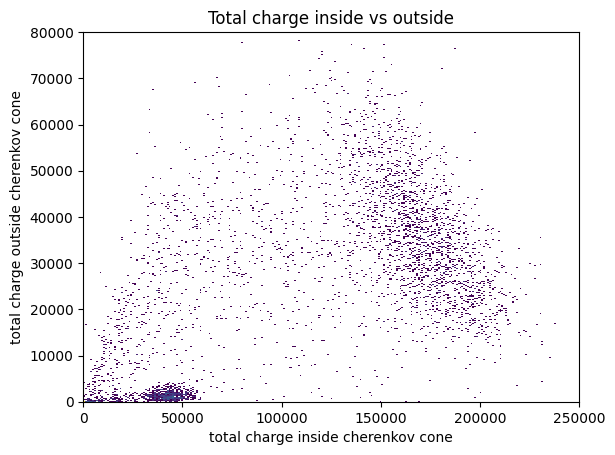

In [97]:

a = np.linspace(np.min(sum_q_tc), np.max(sum_q_ac), 100)


# find total charge deposited outside the 
sum_q_outside = np.abs(sum_q_tc - sum_q_ac)


plt.figure()
plt.hist2d( sum_q_ac, sum_q_outside, bins=(500,500), norm = LogNorm(), alpha = 1)
#plt.plot(a, a , alpha = 0.1, color = 'c')
plt.xlabel("total charge inside cherenkov cone")
plt.ylabel("total charge outside cherenkov cone")
plt.title("Total charge inside vs outside")
#plt.axhline(4000)
plt.xlim([0,250000])
plt.ylim([0,80000])

plt.show()


In [98]:

# tolerance for total charge outside the cone (adjust as needed)
tol1 = 4000  #select events with total charge deposited bigger than this value for shower (or hard scattering) like events
tol2 = 3800  #select events with total charge deposited smaller than this value for track like events

mask_e_like = sum_q_outside > tol1
mask_not_e = sum_q_outside < tol2

# charge measure
charge =  sum_q_ac

# define thresholds for low / medium / high charge deposited inside the Cherenkov cone  for track like events
vals = charge[mask_not_e]
vals = vals[vals > 0]   # ignore zeros
percentiles = [1, 23, 23.1, 96, 96.1, 99.99]
cuts = np.percentile(vals, percentiles)

low_mask    = mask_not_e & (charge > cuts[0]) & (charge <= cuts[1]) #blue
mid_mask = mask_not_e & (charge > cuts[2]) & (charge <= cuts[3]) #green
high_mask   = mask_not_e &(charge > cuts[4]) & (charge <= cuts[5]) #orange
# indices of events
low_events    = np.where(low_mask)[0]
mid_events    = np.where(mid_mask)[0]
high_events   = np.where(high_mask)[0]

# define thresholds for low / medium / high charge deposited inside the Cherenkov cone for shower like events
vals = charge[mask_e_like]
vals = vals[vals > 0]   # ignore zeros
cuts_e = np.percentile(vals, [0.1, 13, 28, 99.9999])

low_mask_e    = mask_e_like & (charge > cuts_e[0]) & (charge <= cuts_e[1]) #purple
mid_mask_e    = mask_e_like & (charge > cuts_e[1]) & (charge <= cuts_e[2]) #pink
high_mask_e = mask_e_like & (charge > cuts_e[2]) & (charge <= cuts_e[3])   #magenta
# indices of events
low_events_e    = np.where(low_mask_e)[0]
mid_events_e    = np.where(mid_mask_e)[0]
high_events_e   = np.where(high_mask_e)[0]

print(f"Low charge: {low_events.size}, Medium charge: {mid_events.size}, High charge: {high_events.size}, Low charge e like: {low_events_e.size},Medium charge e like: {mid_events_e.size}, High charge e like: {high_events_e.size}")


Low charge: 198, Medium charge: 659, High charge: 35, Low charge e like: 403,Medium charge e like: 469, High charge e like: 2251


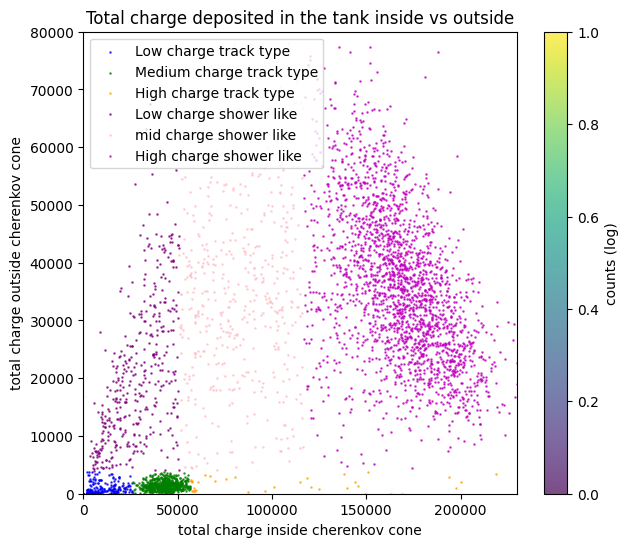

In [99]:

a = np.linspace(np.min(sum_q_tc), np.max(sum_q_ac), 100)

plt.figure(figsize=(7,6))

# base 2D histogram
plt.hist2d(sum_q_ac, sum_q_outside,  bins=(500,500), norm=LogNorm(), cmap='Reds', alpha=1)

# diagonal line
#plt.plot(a, a, alpha=0.1, color='c')

# overlay scatter for chosen events
plt.scatter(sum_q_ac[low_events],    sum_q_outside[low_events],    s=0.7, c='blue',  alpha=0.7, label="Low charge track type")
plt.scatter(sum_q_ac[mid_events], sum_q_outside[mid_events], s=0.7, c='green', alpha=0.7, label="Medium charge track type")
plt.scatter(sum_q_ac[high_events],   sum_q_outside[high_events],   s=0.7, c='orange',alpha=0.7, label="High charge track type")

plt.scatter(sum_q_ac[low_events_e],    sum_q_outside[low_events_e],    s=0.7, c='purple',  alpha=0.7, label="Low charge shower like")
plt.scatter(sum_q_ac[mid_events_e],    sum_q_outside[mid_events_e],    s=0.7, c='pink',  alpha=0.7, label="mid charge shower like")
plt.scatter(sum_q_ac[high_events_e],   sum_q_outside[high_events_e],   s=0.7, c='m',alpha=0.7, label="High charge shower like")
plt.xlabel("total charge inside cherenkov cone")
plt.ylabel("total charge outside cherenkov cone")
plt.title("Total charge deposited in the tank inside vs outside")


plt.xlim([0,230000])
plt.ylim([0,80000])
plt.legend()
plt.colorbar(label="counts (log)")
plt.show()


In [56]:
#save event IDs to later check them in beam monitor detectors
np.savez(f"charge_splits_r{run_number}.npz",
         cuts=cuts,
         low=low_events,
         mid=mid_events,
         high=high_events,
         low_elike=low_events_e,
         mid_elike=mid_events_e,
         high_elike=high_events_e

        )


(2014,)


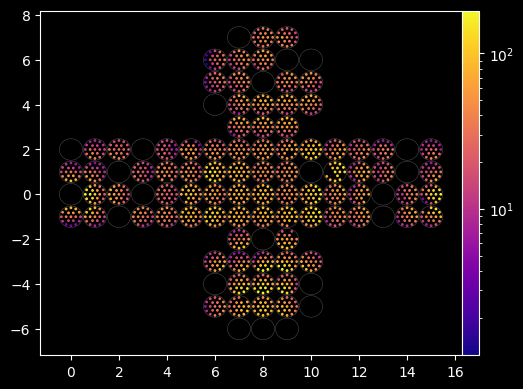

In [70]:
nEvents = 0 
pmt_slot = []
pmt_pos = []
data_to_plot = []

for event in all_events[low_events]:
    #filter out windows which fail the data quality checks 
    if event['window_data_quality']!=0:
        continue
    nEvents+=1
    
    hit_mask = (event['hit_pmt_readout_mask']==0) & (event['hit_mpmt_card_ids']<120)
    
    pmt_slot.extend(event['hit_mpmt_slot_ids'][hit_mask])
    pmt_pos.extend(event['hit_pmt_position_ids'][hit_mask])
    data_to_plot.extend(event['hit_pmt_charges'][hit_mask])

ev_disp_data = eventDisplay.process_data(pmt_slot,pmt_pos,data_to_plot,sum_data=True)
#average by each event
ev_disp_data = ev_disp_data/nEvents 
eventDisplay.plotEventDisplay(ev_disp_data,color_norm=colors.LogNorm(), style= "dark_background")
plt.show(block=False)
plt.style.use('default')